# Initialize cosmocnc

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # Limit to 1 thread
import numpy as np
import matplotlib.pyplot as plt
import pylab as pl
import cosmocnc
from cosmocnc.cnc import cluster_number_counts
from cosmocnc.params import cnc_params_default, cosmo_params_default, scaling_relation_params_default
import jax.numpy as jnp
import jax
import tszpower as tsz
# -------------------------
# 1) Configure cosmocnc params
# -------------------------
cnc_params = cnc_params_default.copy()

# Theory-only (no catalogue needed)
cnc_params["load_catalogue"] = False
# cnc_params["cluster_catalogue"] = "SO_sim_0"

# Backends
cnc_params["cosmology_tool"] = "classy_sz"
cnc_params["hmf_calc"] = "cnc"
# cnc_params["hmf_calc"] = "classy_sz"

cnc_params["survey_sr"] = "/scratch/scratch-lxu/cosmocnc/surveys/survey_sr_planck_sim.py"
cnc_params["survey_cat"] = "/scratch/scratch-lxu/cosmocnc/surveys/survey_cat_so_sim.py"

# Selection observable
cnc_params["obs_select"] = "q_planck_sim"
cnc_params["observables"] = [["q_planck_sim"]]
cnc_params["interp_tinker"] = "log"

# Ranges
cnc_params["M_min"] = 1e14
cnc_params["M_max"] = 1e16
cnc_params["z_min"] = 0.005
cnc_params["z_max"] = 3.0
cnc_params["obs_select_min"] = 5.0
cnc_params["obs_select_max"] = 200.0

# Resolution
cnc_params["n_points"] = 16384 #number of points in which the mass function at each redshift (and all the convolutions) is evaluated
cnc_params["n_points_data_lik"] = 2048 #number of points in which the mass function at each redshift (and all the convolutions) is evaluated
cnc_params["n_z"] = 2048

#Parameters for the binned likelihood

cnc_params["binned_lik_type"] = "z_and_obs_select"
cnc_params["bins_edges_z"] = np.linspace(cnc_params["z_min"],cnc_params["z_max"],20)
cnc_params["bins_edges_obs_select"] = np.exp(np.linspace(np.log(cnc_params["obs_select_min"]),np.log(cnc_params["obs_select_max"]),20))

#Stacked data, set to False for now

cnc_params["stacked_likelihood"] = False
cnc_params["stacked_data"] = ["p_so_sim_stacked"] #list of stacked data
cnc_params["compute_stacked_cov"] = True


cnc_params["data_lik_from_abundance"] = False
cnc_params["likelihood_type"] = "binned"

# Quiet logs
cnc_params["cosmocnc_verbose"] = "minimal"

defaulting to  /rds-d4/user/iz221/hpc-work/cosmopower/
defaulting to  /scratch/scratch-lxu/cosmocnc/cosmocnc/../


2026-01-16 10:51:50.267350: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
/scratch/scratch-lxu/tszsbi/tszpower/__init__.py:1: DeprecationWarning: compute_class_szfast is deprecated. Use initialize_classy_szfast instead.
  from .config import classy_sz
/scratch/scratch-lxu/venv/cmbagent_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
cnc = cosmocnc.cluster_number_counts(cnc_params = cnc_params)
cnc.initialise()

/scratch/scratch-lxu/cosmocnc/cosmocnc/cnc.py:65: DeprecationWarning: compute_class_szfast is deprecated. Use initialize_classy_szfast instead.
  self.cosmology = cosmology_model(cosmo_params=self.cosmo_params,
/scratch/scratch-lxu/venv/cmbagent_env/lib/python3.12/site-packages/mcfit/mcfit.py:130: UserWarning: use backend='jax' if desired
  warnings.warn("use backend='jax' if desired")


# Initialize tszpower

In [3]:
allpars = {
    'omega_b': 0.022245895720000002,
    'omega_cdm':  0.12085104428000001,
    'H0': 67.4,
    'tau_reio': 0.0544,
    'ln10^{10}A_s': 3.037195662,
    # 'sigma8': 0.81,
    'n_s': 0.96,
    "cosmo_model": 0, # 1: use mnu-lcdm emulators; 0: use lcdm with fixed neutrino mass
    "B": 1.61,

    'M_min': 1e14*0.674,
    'M_max': 1e16*0.674,

    'z_min' : 0.005,
    'z_max' : 3.0,

    "P0GNFW": 8.130,
    "c500": 1.156,
    "gammaGNFW": 0.3292,
    "alphaGNFW": 1.0620,
    "betaGNFW":5.4807,

    'jax' : 1, 
}
tsz.classy_sz.set(allpars)
tsz.initialise()

/tmp/ipykernel_3524421/910841446.py:27: DeprecationWarning: compute_class_szfast is deprecated. Use initialize_classy_szfast instead.
  tsz.initialise()


# Update scaling relation parameters

In [4]:
scal_rel_params = scaling_relation_params_default.copy()
scal_rel_params["A_szifi"] = -4.218089337196837
scal_rel_params["alpha_szifi"] = 1.12

cnc.update_params(cosmo_params_default, scal_rel_params)

/scratch/scratch-lxu/cosmocnc/cosmocnc/cnc.py:138: DeprecationWarning: compute_class_szfast is deprecated. Use initialize_classy_szfast instead.
  self.cosmology.update_cosmology(cosmo_params,cosmology_tool=self.cnc_params["cosmology_tool"])
/scratch/scratch-lxu/venv/cmbagent_env/lib/python3.12/site-packages/mcfit/mcfit.py:130: UserWarning: use backend='jax' if desired
  warnings.warn("use backend='jax' if desired")


# Cluster abundance in cosmocnc

In [5]:
cnc.get_number_counts()
cnc.get_cluster_abundance()
cnc.get_abundance_matrix()

In [6]:
cnc.n_tot

np.float64(1446.4485194268657)

In [7]:
cnc.get_log_lik_binned()

0.0

In [8]:
cnc_params["likelihood_type"] = "binned"
cnc_params["obs_select_min"] = 5.000

bins_centres_z = cnc.bins_centres_z #z bins centres
bins_centres_snr = cnc.bins_centres_obs #SNR bins centres

n_binned_theory = cnc.n_binned
n_tot_bins_theory = np.sum(n_binned_theory)
n_binned_snr_theory = np.sum(n_binned_theory,axis=0)
n_binned_z_theory = np.sum(n_binned_theory,axis=1)
print("Predicted total number of clusters in the bins = ",n_tot_bins_theory,"+-",np.sqrt(n_tot_bins_theory))

Predicted total number of clusters in the bins =  1446.1753974857575 +- 38.02861287880163


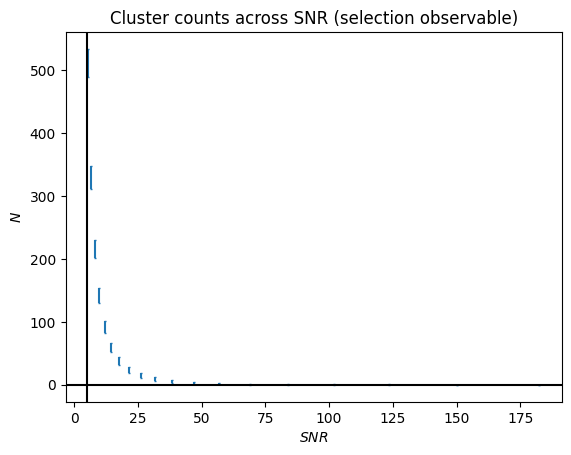

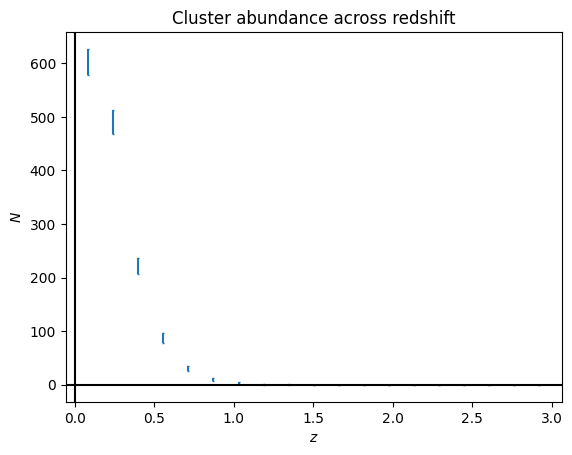

In [9]:
size_marker = 1

pl.errorbar(bins_centres_snr,n_binned_snr_theory,yerr=np.sqrt(n_binned_snr_theory),color="tab:blue",
            linestyle="none",fmt="",capsize=size_marker)
pl.xlabel("$SNR$")
pl.ylabel("$N$")
pl.axvline(x=5.,color="k")
pl.axhline(y=0.,color="k")
pl.title("Cluster counts across SNR (selection observable)")
pl.show()

pl.errorbar(bins_centres_z,n_binned_z_theory,yerr=np.sqrt(n_binned_z_theory),color="tab:blue",
            linestyle="none",fmt="",capsize=size_marker)
pl.xlabel("$z$")
pl.ylabel("$N$")
pl.axvline(x=0.,color="k")
pl.axhline(y=0.,color="k")
pl.title("Cluster abundance across redshift")
pl.show()

In [10]:
bins_centres_z

array([0.08381579, 0.24144737, 0.39907895, 0.55671053, 0.71434211,
       0.87197368, 1.02960526, 1.18723684, 1.34486842, 1.5025    ,
       1.66013158, 1.81776316, 1.97539474, 2.13302632, 2.29065789,
       2.44828947, 2.60592105, 2.76355263, 2.92118421])

# Cluster abundance in tszpower

In [11]:
# use cosmocnc binning information
z_edges = jnp.asarray(cnc_params["bins_edges_z"])
q_edges = jnp.asarray(cnc_params["bins_edges_obs_select"])

Nz, Nq = tsz.compute_cluster_counts_in_z_q_bins_completeness(
    params_values_dict=allpars,
    sigma_lnY=0.173,

    # z binning
    z_edges=z_edges,

    # q / SNR binning
    q_edges=q_edges,
    f_sky=1.0,
    n_grid=4096,
    nsig=16.0,
)


In [12]:
Nz.shape, Nq.shape

((19,), (19,))

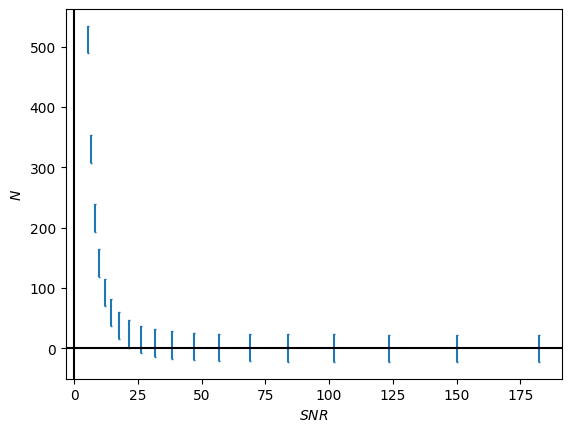

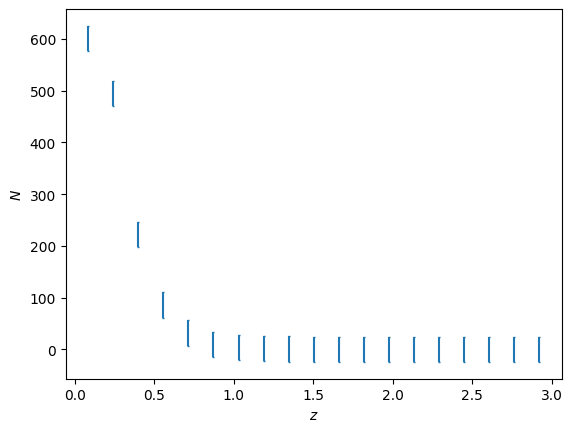

In [13]:
size_marker = 1

pl.errorbar(bins_centres_snr,Nq,yerr=np.sqrt(Nq[0]),color="tab:blue",
            linestyle="none",fmt="",capsize=size_marker)
pl.xlabel("$SNR$")
pl.ylabel("$N$")
pl.axvline(x=0.,color="k")
pl.axhline(y=0.,color="k")

pl.show()

pl.errorbar(bins_centres_z,Nz,yerr=np.sqrt(Nz[0]),color="tab:blue",
            linestyle="none",fmt="",capsize=size_marker)
pl.xlabel("$z$")
pl.ylabel("$N$")

pl.show()



# Compare tszpower witt cosmocnc

In [14]:
Nq/n_binned_snr_theory

Array([1.00185912, 1.00126947, 1.00124898, 1.00120375, 1.00115999,
       1.00114895, 1.00114467, 1.00113967, 1.00113407, 1.00113178,
       1.0011352 , 1.00114211, 1.00114902, 1.00115365, 1.00115404,
       1.00114709, 1.0011276 , 1.00108921, 1.00102542], dtype=float64)

In [15]:
Nz/n_binned_z_theory

Array([0.99779563, 1.00949011, 0.99844972, 0.9817815 , 1.02427411,
       1.00727008, 0.97382273, 1.02807365, 0.94520535, 1.01231507,
       1.03316225, 1.02376285, 1.00490895, 1.02687423, 1.01957432,
       0.95406225, 1.01476026, 0.92969979, 0.97826994], dtype=float64)

In [16]:
np.sum(n_binned_snr_theory)
np.sum(Nz)
np.sum(n_binned_z_theory)

np.float64(1446.1753974857577)

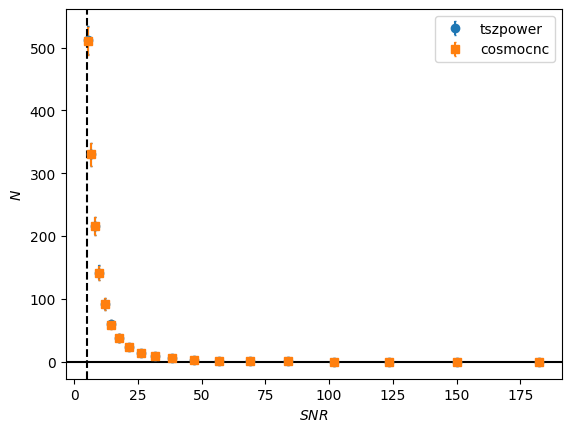

In [17]:
size_marker = 1

pl.figure()

# tszpower
pl.errorbar(
    bins_centres_snr,
    Nq,
    yerr=np.sqrt(Nq),
    color="tab:blue",
    linestyle="none",
    fmt="o",
    capsize=size_marker,
    label="tszpower",
)

# cosmocnc
pl.errorbar(
    bins_centres_snr,
    n_binned_snr_theory,
    yerr=np.sqrt(n_binned_snr_theory),
    color="tab:orange",
    linestyle="none",
    fmt="s",
    capsize=size_marker,
    label="cosmocnc",
)

pl.axvline(x=5.0, color="k", linestyle="--")
pl.axhline(y=0.0, color="k")

pl.xlabel("$SNR$")
pl.ylabel("$N$")
pl.legend()
pl.show()


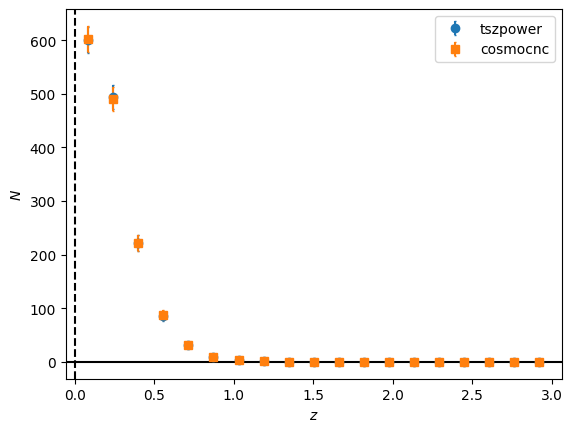

In [18]:
pl.figure()

# tszpower
pl.errorbar(
    bins_centres_z,
    Nz,
    yerr=np.sqrt(Nz),
    color="tab:blue",
    linestyle="none",
    fmt="o",
    capsize=size_marker,
    label="tszpower",
)

# cosmocnc
pl.errorbar(
    bins_centres_z,
    n_binned_z_theory,
    yerr=np.sqrt(n_binned_z_theory),
    color="tab:orange",
    linestyle="none",
    fmt="s",
    capsize=size_marker,
    label="cosmocnc",
)

pl.axvline(x=0.0, color="k", linestyle="--")
pl.axhline(y=0.0, color="k")

pl.xlabel("$z$")
pl.ylabel("$N$")
pl.legend()
pl.show()
